# Introducrtion to Machine Learning: Assignment #2
## Submission date: 06\01\2025, 23:59.
### Topics:
- Perceptron
- Logistic Regression
- Gradient Descent
- SVM
- Kernels

Submitted by:
Lian Natour 207300443

**Assignment Instruction:**

· Submissions in pairs only.

· Try to keep the code as clean, concise, and short as possible

· If you wish to work in your IDE, you can, but you **must**,  insert the script back to the matching cells of the notebook and run the code. <br/>Only the notebook will be submitted in moodle (in `.ipynb` format).

· <font color='red'>Please write your answers to question in red</font>.

**Important:** All plots, results and outputs should be included in the notebook as the cells' outputs (run all cells and do not clear the output). <br/>

**Important:** Your submission must be entirely your own. Any attempts of plagiarism (including ChatGPT) will lead to grade 0 and disciplinary actions.


## Question 1 - Logistic regression - Part 1

In this section you will build a classifier on a "toy" problem - Based on two grades, we determine if student passes the course or not.

import libraries and load dataset

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('https://sharon.srworkspace.com/ml/datasets/hw2/exams.csv', header=None)
df.head(3)

,0,1,2
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0


Now, lets preproccess:
- Convert dataset to numpy, make sure classes are {0,1} or {-1,1} (depends of the update rule you choose)
- Split to train & test (80-20, stratify, random_state=42)
- Scale the data

<font color='red'>Explain here your scaler choice

I chose StandardScaler because it normalizes data, ensuring features contribute
equally to the model. This helps logistic regression learn faster and more effectively.</font>

In [106]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#Splitting the dataset into features and target variable
data = df.values
X = data[:, :-1]
y = data[:, -1]

#Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Scaling the data using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Implement here

Implement the function `Logistic_Regression_via_GD(X, y, lr)`:
-	Input: the training data $X\in\mathbb{R}^{n\times d}$, a label vector $y\in\{0,1\}^n$ and learning rate parameter ‘lr’.
-	Output: The function computes the output vector ‘w’ (and ‘b’) which minimzes the logistic regression cost function on ‘X’ and ‘y’. <br/>

The implementation should be _fully yours_. Don't use library implementation! <br/>
It should be done by implementing Gradient descent (with ‘lr’ as the learning rate) to solve logistic regression. <br/>

Tip: The gradients may be large, you can use $\frac{1}{n}\nabla{L}$ (which is the true empirical loss' gradient)



In [107]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

def Logistic_Regression_via_GD(X, y, lr):
 #Initialize weights and bias
    num_features = X.shape[1]
    w = np.zeros(num_features)
    b = 0.0

    num_samples = X.shape[0]

    for i in range(60000):
        #Calculate the model predictions
        z = np.dot(X, w) + b
        predictions = sigmoid(z)

        #Compute gradients
        gradient_w = (1 / num_samples) * np.dot(X.T, (predictions - y))
        gradient_b = (1 / num_samples) * np.sum(predictions - y)

        #Update weights and bias
        w -= lr * gradient_w
        b -= lr * gradient_b

    return w, b

The function 'predict' is already implemented for you. It gives a classification for a new sample (x) based on the sign of $w^\top x + b$. <br/>
You may change it if you chose to return {+1,0} instead of {+1,-1}.

In [108]:
def predict(w,b,x):
    return np.where(np.dot(x, w) + b > 0, 1, 0)

Call `Logistic_Regression_via_GD(X,y,lr)`, where ‘X’ and ‘y’ are the training data and the corresponding labels. <br/>
Run the model on the test data. With good LR you should get accuracy >= 88\%

In [109]:
chosen_lr = 0.01
w, b = Logistic_Regression_via_GD(X_train, y_train, chosen_lr)

preds = predict(w, b, X_test)
accuracy = np.sum(preds == y_test) / len(y_test)
print(f"Test accuracy is {accuracy * 100}%")

Test accuracy is 95.0%


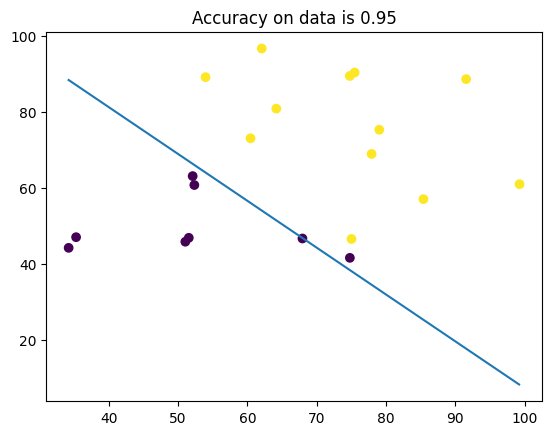

In [ ]:
#@title Visualize data (on test)

import matplotlib.pyplot as plt

def plot(data, labels, w, bias):

    plt.scatter(data[:,0], data[:,1], c=labels)

    a, b, c = w[0], w[1], bias

    m = -a / b
    b = -c / b

    x = np.arange(np.min(data[:,0]), np.max(data[:,0]), 0.1)
    y = m * x + b

    plt.plot(x, y)

    preds = predict(w, bias, data)
    acc = np.count_nonzero(labels == preds) / len(labels)
    plt.title(f"Accuracy on data is {acc}")

    plt.show()

plot(X_test, y_test, w, b)

## Question 1 - Logistic regression - Part 2
Now we are going to work on a much realistic problem - based on IMDB review, classify whether its positive or negative review.

In [110]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gensim
from gensim.models import Word2Vec
import os

Print first review

In [111]:

df = pd.read_csv('IMDB Dataset.csv')    # you may change the path according to your drive

print(f"The dataset shape is {df.shape}")

# print the first line
print(df.iloc[0].review)
print(df.iloc[0].sentiment)

The dataset shape is (50000, 2)
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appe

As you can see, the input is a <b>sentence</b>. The proccess of turning words into <u>meaningful</u> continious vectors is called "tokenization" (you will learn more in DL and NLP).

In the next section you will load the model and proccess the reviews to obtain continious representation for the data

In [112]:
#@title Model loader function

MODEL_PATH = 'wordvec.model'

def load_model(data):
	if os.path.exists(MODEL_PATH):
		return gensim.models.Word2Vec.load(MODEL_PATH)
	else:
		model = Word2Vec(sentences=data, vector_size=100, window=5, min_count=1)
		model.save(MODEL_PATH)
		return model

In [113]:
sentences = df['review'].tolist()

# turn sentences into a list. Each sentence is an array of words
tokenized_sentences = [[token for token in row.split()] for row in sentences]

# will ~3 minutes. The model is saved to a LOCAL path.
model = load_model(tokenized_sentences)     # calls to "model loader function" above.

In [ ]:
word_vectors = model.wv
print(word_vectors['wow'].shape)
print(word_vectors['wow'])

(100,)
[ 0.19050333  0.06939059  0.19949757 -0.0417868  -0.07916684 -0.02266091
  0.0466329   0.6262003  -0.46028572 -0.31039214  0.00076401 -0.22373357
 -0.22775774  0.17972161  0.31551307 -0.18027262  0.10121386 -0.20902431
 -0.10302781 -0.39829    -0.02624559  0.14390482  0.16532394 -0.09827477
 -0.24663846  0.44501385 -0.36123928  0.09397247  0.1014801   0.1727133
  0.10691576  0.0702473  -0.02854457 -0.27100867 -0.06599729  0.40180692
  0.14322539 -0.05939831 -0.19206029 -0.23261775 -0.23579866 -0.11928469
  0.60713434  0.140328    0.02298152 -0.13141881 -0.29458597 -0.02370681
  0.13222301  0.1521152   0.29903945 -0.39717323 -0.16749248 -0.03119515
  0.13097623  0.16136582 -0.06296185  0.15912232  0.40279546  0.13627137
 -0.1291333   0.00155977 -0.08769216  0.12013823 -0.14358966  0.05953466
  0.28183565  0.13593762 -0.35173744  0.07030885 -0.21113484  0.01045746
 -0.03150405 -0.14819136  0.3456163   0.24880347 -0.11416844 -0.14520386
  0.14896953 -0.14469795 -0.04291468  0.44667

As you can see, each word has now 100 features. <br/>
For simplicity, you will represent a sentence by the mean vector of all the words within it. <br/>
Your tasks are: <br/>
- Make sure classes are {0,1} or {-1,1} (depends of the update rule you choose). You can change that row.
- Construct X to be 50000 x 100, where each row represents a sentnce.
- Convert it to numpy.

In [114]:
y = df['sentiment'].replace({'positive': 1, 'negative': 0}).to_numpy()


def review_to_vec(review, model):
    # Tokenize the review and filter out words not in the model's vocabulary
    words = review.split()
    word_vecs = [model.wv[word] for word in words if word in model.wv]

    # Calculate the mean vector of the words in the review
    if len(word_vecs) > 0:
        mean_vec = np.mean(word_vecs, axis=0)
    else:
        # If no words in the review are in the model's vocabulary, use a zero vector
        mean_vec = np.zeros((100,))
    return mean_vec

# Apply the function to each review and stack the vectors to form the matrix X
X = np.vstack(df['review'].apply(lambda x: review_to_vec(x, model)))

# Convert X to a numpy array (if it's not already)
X = np.array(X)

<ipython-input-114-6ea9282e3e6d>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df['sentiment'].replace({'positive': 1, 'negative': 0}).to_numpy()


Split the data into 20\% test and 80\% train. After that, split the train into smaller train and 20% validation. Use stratify and random state of 42\%

In [115]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

Now, scale the data <br/>
Guide:
- When you check the performance on the validation, you want to use the tiny train, so the scaling should be relative to it as well.
- When you evaluate the performance on the final test, you don't want to lose data, as the validation creation was synthetic for improving the model. Hence, you will use the big train (train + val). The scaling should be relative to it as well.

We discussed this on the second tutorial<br/>


In [116]:
X_train_val = np.vstack((X_train, X_val))
y_train_val = np.hstack((y_train, y_val))

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the combined training and validation data
scaler.fit(X_train_val)

# Transform the training, validation, and test datasets
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Copy here your logistic solver from before and adjust its implementation for this problem, if required.

In [117]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

def Logistic_Regression_via_GD(X, y, lr):
 #Initialize weights and bias
    num_features = X.shape[1]
    w = np.zeros(num_features)
    b = 0.0

    num_samples = X.shape[0]

    for i in range(5000):
        #Calculate the model predictions
        z = np.dot(X, w) + b
        predictions = sigmoid(z)

        #Compute gradients
        gradient_w = (1 / num_samples) * np.dot(X.T, (predictions - y))
        gradient_b = (1 / num_samples) * np.sum(predictions - y)

        #Update weights and bias
        w -= lr * gradient_w
        b -= lr * gradient_b

    return w, b

Train model and evaluate on test set

In [118]:
chosen_lr = 0.2
w, b = Logistic_Regression_via_GD(X_train_scaled, y_train, chosen_lr)

preds = predict(w, b, X_test_scaled)
accuracy = np.sum(preds == y_test) / len(y_test)
print(f"Test accuracy is {accuracy * 100}%")

Test accuracy is 82.36%


Answer the following two questions: <br/>
- Try to justify the accuracy  you got. What could be done differently and potentially improve your success?
- How did you choose your lr? Is it the correct method?

<font color='red'>Write your answers here and explain

 1.The accuracy of 82.36% you achieved suggests that logistic regression is effective to an extent but might be limited by its simplicity,we could change the learning rate or nuber of iterations to get better results.
 2.the learning rate was chosen by trying multiple learning rates and I got spme learning rates that give me the same accuracy , I dont think this is the optimal method . </font>

## Question 2 - Perceptron
You are given dataset for binary classification in 2D and aim to build the best Perceptron classifier.

import libraries

In [119]:
import numpy as np
import matplotlib.pyplot as plt

In [120]:
#@title load npy file

import requests
from io import BytesIO

def load_npy_file(url):
  response = requests.get(url)
  if response.status_code == 200:
    npy_data = np.load(BytesIO(response.content), allow_pickle=True).item()
    return npy_data
  else:
    return None

Load data and make sure labels are appropriate for the perceptron algorithm

Unique labels in training data before: [0 1]
Unique labels in training data after: [-1  1]


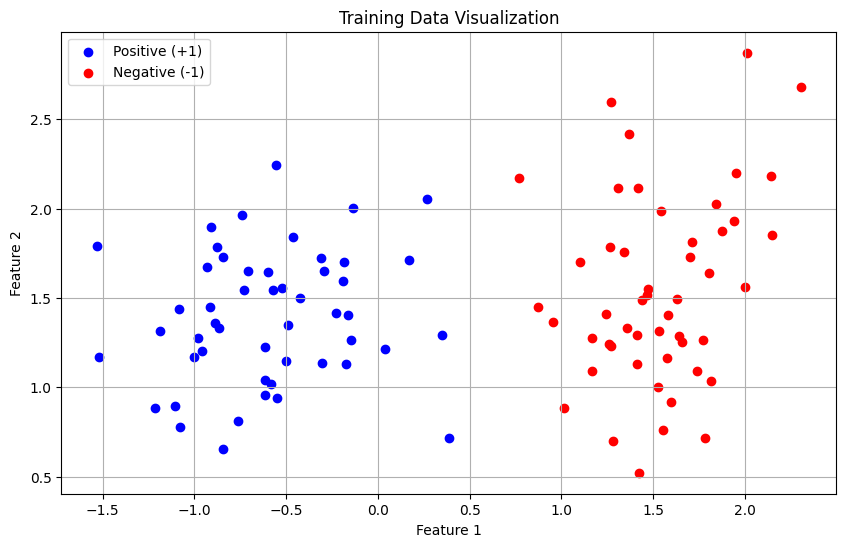

In [121]:
data_dict = load_npy_file('https://sharon.srworkspace.com/ml/datasets/hw2/perceptron_data.npy')

X_train = data_dict['X_train']
y_train = data_dict['y_train']
X_test = data_dict['X_test']
y_test = data_dict['y_test']

# Change labels here if required.
#Check unique values first
print("Unique labels in training data before:", np.unique(y_train))

#Adjust labels if they are in {0, 1}
if 0 in np.unique(y_train):
    y_train = np.where(y_train == 0, -1, 1)
    y_test = np.where(y_test == 0, -1, 1)

print("Unique labels in training data after:", np.unique(y_train))

# Plotting the dataset
plt.figure(figsize=(10, 6))
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='b', label='Positive (+1)')
plt.scatter(X_train[y_train == -1][:, 0], X_train[y_train == -1][:, 1], color='r', label='Negative (-1)')
plt.title('Training Data Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

Implement the function `perceptron(data, labels, lr)` which gets the train data $X\in\mathbb{R}^{n\times d}$, labels and returns the weight vector learned by perceptron.
Demands:
- Use full size batch - at each iteration, update the weights according to all the misclassified points.
- Print the number of *points* been updated untill convergence.



In [122]:
def perceptron(data, labels, lr=1):
    weights = np.zeros(data.shape[1])
    bias = 0
    iterations = 0
    converged = False

    while not converged:
        weight_update = np.zeros(data.shape[1])
        bias_update = 0
        misclassified_count = 0

        # Compute updates for all misclassified points
        for x, y in zip(data, labels):
            if y * (np.dot(x, weights) + bias) <= 0:
                weight_update += y * x
                bias_update += y
                misclassified_count += 1

        # Apply updates if there are misclassified points
        if misclassified_count > 0:
            weights += lr * weight_update
            bias += lr * bias_update
            converged = False
        else:
            converged = True

        # Print the number of points updated in this iteration
        print(f"Iteration {iterations + 1}: Updated {misclassified_count} points")
        iterations += 1

    print("Number of iterations it took to converge is:", iterations)
    return weights, bias



In [123]:
#@title Ploting function
def plot(data, labels, w, bias):

    plt.scatter(data[:,0], data[:,1], c=labels)

    a, b, c = w[0], w[1], bias

    m = -a / b
    b = -c / b

    x = np.arange(0.2, 0.8, 0.1)
    y = m * x + b

    plt.plot(x, y)

    preds = np.sign(np.dot(data, w)+bias)
    acc = np.count_nonzero(labels == preds) / len(labels)
    plt.title(f"Accuracy on data is {acc}")

    plt.show()

Choose LR (doesn't matter how), train and call the plotting function on the <u>train</u>
dataset. It prints the accurcay as the graph's title.
1. What is your conclusion about this data?
2. How would SVM react to such data? Will it perform better?

<font color='red'>Write here your answers and explain them:
              1.The Perceptron model achieves perfect accuracy on the training data and 90% on the test set, indicating that the data is mostly linearly separable
              2.The SVM is designed to maximize the margin between classes, could potentially perform better, especially if there's a need to manage outliers or if the classes aren't perfectly linearly separable. Using SVM might improve generalization on the test
              set.                             
               </font>

Iteration 1: Updated 100 points
Iteration 2: Updated 6 points
Iteration 3: Updated 4 points
Iteration 4: Updated 3 points
Iteration 5: Updated 2 points
Iteration 6: Updated 2 points
Iteration 7: Updated 1 points
Iteration 8: Updated 1 points
Iteration 9: Updated 1 points
Iteration 10: Updated 1 points
Iteration 11: Updated 1 points
Iteration 12: Updated 1 points
Iteration 13: Updated 1 points
Iteration 14: Updated 0 points
Number of iterations it took to converge is: 14


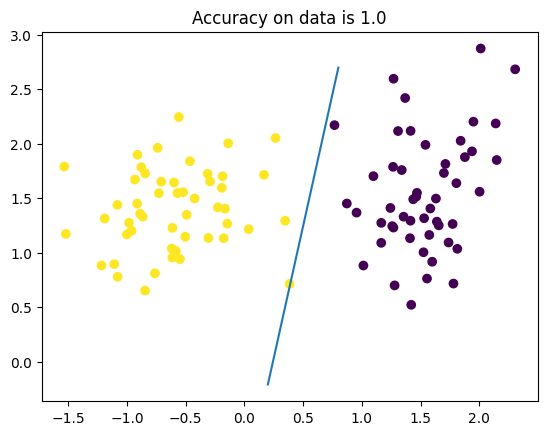

In [124]:
chosen_lr =0.03
w,b = perceptron(X_train, y_train, chosen_lr)

plot(X_train, y_train, w, b)

Print the test accuracy

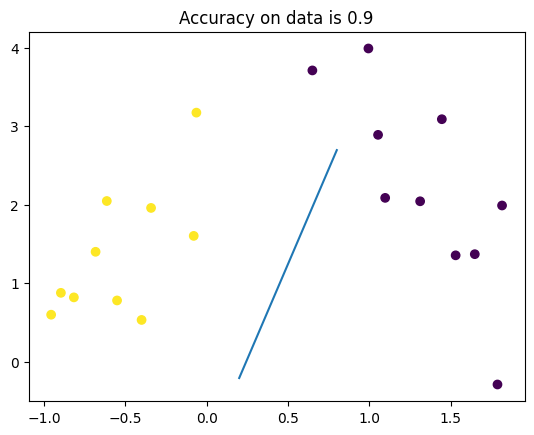

In [125]:
preds = np.sign(np.dot(X_test, w) + b)
acc = np.count_nonzero(y_test == preds) / len(y_test)
plot(X_test, y_test, w, b)

Time for some convergence theory! </br>

Let ${\{x_i\} }_{i=1}^n$ be the training set and define $R=\text{sup}\{‖x_1‖,...,‖x_n‖\}$.

Now let $\gamma$ be the smallest margin from point in the training set to the _separating hyperplace_.

Then, the number of iterations required for convergence is bounded (from above) by $k=R^2/\gamma^2$. However, this is achieved only when using single batch method.

According to this method, update below the perceptron function to work with single batch (at each iteration only one misclassified sample update) and use the same LR. Call the function using $k$ as the upper bound on the iterations number.

1. How many single points updates were in your first implementation?
2. Did the iterations number improve?

<font color='red'>Write here your answer
1.To find the total number of single-point updates,we add up all the updates from each iteration:100 + 6 + 4 + 3 + 2 + 2 + 1 + 1 + 1 + 1 + 1 + 1 + 1 = 124
So, there were 124 single-point updates in the sense that 124 individual points  were misclassified and caused the model to update at some point in the training process.

2.
No, the number of iterations did not improve with the single-update approach; it increased from 14 to 17 iterations compared to the original batch update method.</font>


In [126]:
import numpy as np

def perceptron_updated(data, labels, lr=1):
    #Initialize weights and bias
    weights = np.zeros(data.shape[1])
    bias = 0

    #Compute R
    R = np.max(np.linalg.norm(data, axis=1))

    #Initial weights for gamma calculation
    initial_weights = np.random.randn(data.shape[1]) * 0.01
    initial_bias = 0

    #Compute gamma
    gamma = np.min([labels[i] * np.dot(data[i], data[i]) for i in range(len(labels)) if labels[i] * np.dot(data[i], data[i]) > 0])

    #Set theoretical upper bound on iterations
    max_iterations = int((R ** 2) / (gamma ** 2))

    iterations = 0
    converged = False

    while not converged and iterations < max_iterations:
        converged = True
        for x, y in zip(data, labels):
            if y * (np.dot(x, weights) + bias) <= 0:
                weights += lr * y * x
                bias += lr * y
                converged = False
                break  # Update only on the first misclassified point and then break
        iterations += 1

    print(f"Converged in {iterations} iterations with max iterations allowed: {max_iterations}")
    print(f"Training accuracy: {accuracy * 100:.2f}%")

    return weights, bias

Report the train accuracy.

Converged in 17 iterations with max iterations allowed: 28
Training accuracy: 82.36%


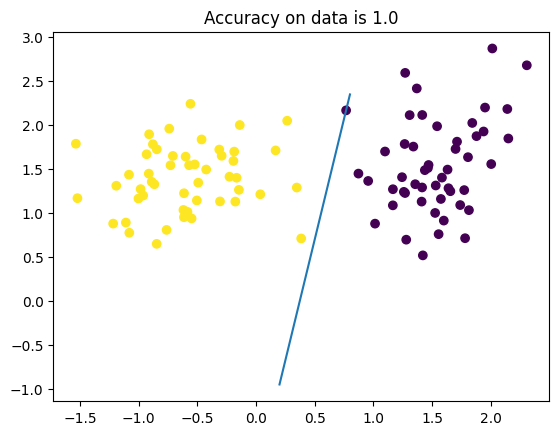

In [127]:
chosen_lr = 0.2
w,b = perceptron_updated(X_train, y_train, chosen_lr)

plot(X_train, y_train, w, b)

Report the test accuracy. Did it improve? What can you conclude about the perceptron algorithm in the linear separable case?
The accuracy remained consistent, demonstrating that the Perceptron algorithm is effective at handling linearly separable data. It didn't require the maximum allowed iterations to find a suitable separating line.

Test accuracy is 90.0%


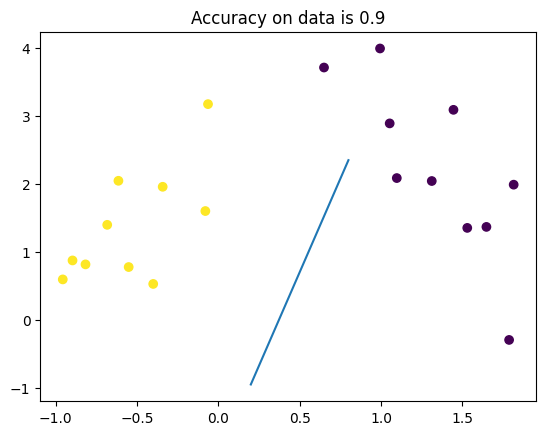

In [128]:
preds = np.sign(np.dot(X_test, w) + b)
acc = np.count_nonzero(y_test == preds) / len(y_test)
print(f"Test accuracy is {acc*100}%")
plot(X_test, y_test, w, b)

## Question 3 - SVM

You are given dataset for binary classification in 2D and aim to build the best SVM classifier.

import libraries

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

In [130]:
#@title load npy file

import requests
from io import BytesIO

def load_npy_file(url):
  response = requests.get(url)
  if response.status_code == 200:
    npy_data = np.load(BytesIO(response.content), allow_pickle=True).item()
    return npy_data
  else:
    return None

load the data

In [131]:
data_dict = load_npy_file('https://sharon.srworkspace.com/ml/datasets/hw2/svm_data_2d.npy')

# Access the data as needed
X_train = data_dict['X_train']
y_train = data_dict['y_train']
X_val = data_dict['X_val']
y_val = data_dict['y_val']

Look at the plot of the training data. <br/>
What _geometric_ shape could (almost) perfectly separate the data?<br/>

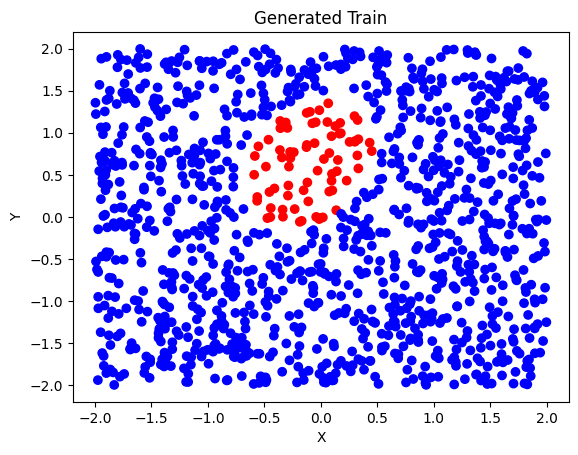

In [132]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Generated Train')
plt.show()

Hope you answered ellipsoid! <br/>
Its equation is:
$$Ax^2+By^2+Cx+Dy+Exy+f=0$$
Based on that equation, construct a mapping function into 5d space, such that the problem will become a linear ($w^t ϕ(x)+e=0$). <br/>
After the mapping, learn a linear classifier and print the hyperplane equation.<br/>
Note: after getting an output, I would recommend you to plot this equation on <a href="https://www.desmos.com/calculator">desmos</a>, just to "see it".

In [133]:
def transform_features(X):
    x_squared = X[:, 0]**2
    y_squared = X[:, 1]**2
    x = X[:, 0]
    y = X[:, 1]
    xy = X[:, 0] * X[:, 1]
    return np.column_stack((x_squared, y_squared, x, y, xy))

new_features = transform_features(X_train)


model = SVC(kernel='linear', C=3)
model.fit(new_features, y_train)

# Get the hyperplane equation coefficients and intercept
coefficients = model.coef_[0]
intercept = model.intercept_

# Print the hyperplane equation
equation_parts = []
for i in range(len(coefficients)):
    equation_parts.append(f"({coefficients[i]:.3f} * X{i+1})")
equation = " + ".join(equation_parts) + f" + ({intercept[0]:.3f})"

print("Hyperplane equation:")
print(f"  {equation}")

Hyperplane equation:
  (-7.457 * X1) + (-3.974 * X2) + (-3.153 * X3) + (5.107 * X4) + (2.583 * X5) + (0.569)


Complete the missing lines to get plots on train and test

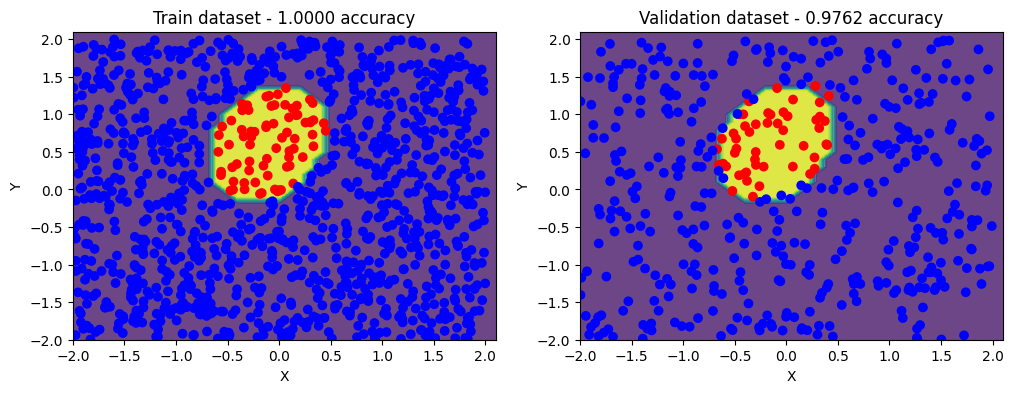

In [134]:
train_features = transform_features(X_train)
train_preds = model.predict(train_features)
train_acc = np.mean(train_preds == y_train)

val_features = transform_features(X_val)
val_preds = model.predict(val_features)
val_acc = np.mean(val_preds == y_val)

xx, yy = np.meshgrid(np.arange(-2, 2.2, 0.1), np.arange(-2, 2.2, 0.1))
data = np.c_[xx.ravel(), yy.ravel()]

new_features = transform_features(data)
Z = model.predict(new_features)
Z = Z.reshape(xx.shape)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plot the training data on the first subplot
axs[0].contourf(xx, yy, Z, alpha=0.8)
scatter1 = axs[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_title(f'Train dataset - {train_acc:.4f} accuracy')

# Plot the validation data on the second subplot
axs[1].contourf(xx, yy, Z, alpha=0.8)
scatter2 = axs[1].scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap='bwr')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Y')
axs[1].set_title(f'Validation dataset - {val_acc:.4f} accuracy')

plt.show()

You will try also two other kernels:
  - kernel='poly', degree=4, C=3.
  -	kernel='rbf', gamma=1, C=1.

Based on those two models, _along_ with the ellipsoid, which model generalizes the best? <br/>
<font color='red'>Write here your answer and explain it

The RBF kernel SVM model generalizes the best, achieving the highest validation accuracy compared to the polynomial and ellipsoidal models. Its flexibility in handling various data distributions makes it the most effective choice.</font>

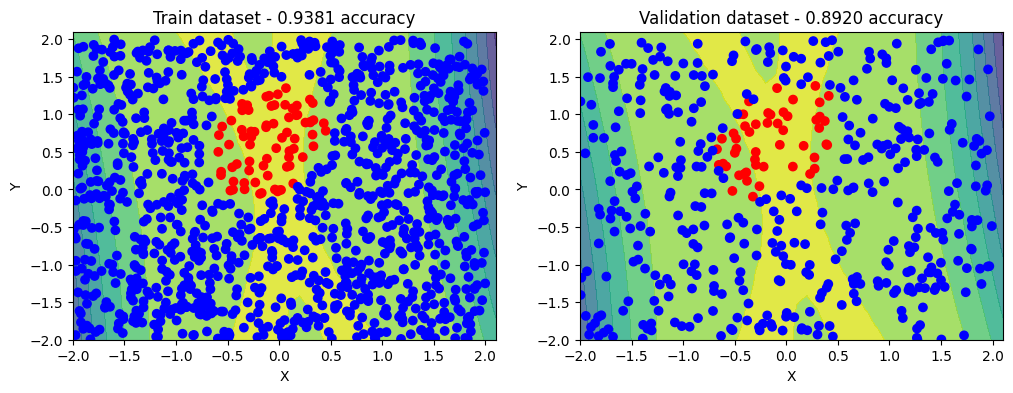

In [135]:
from sklearn.svm import SVC

model =SVC(kernel='poly', degree=4,  C=3)
clf = model.fit(X_train, y_train)

xx, yy = np.meshgrid(np.arange(-2, 2.2, 0.1), np.arange(-2, 2.2, 0.1))
xy = np.c_[xx.ravel(), yy.ravel()]

P = model.decision_function(xy).reshape(xx.shape)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plot the training data on the first subplot
axs[0].contourf(xx, yy, P, alpha=0.8)
scatter1 = axs[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_title(f'Train dataset - {clf.score(X_train, y_train):.4f} accuracy')

# Plot the validation data on the second subplot
axs[1].contourf(xx, yy, P, alpha=0.8)
scatter2 = axs[1].scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap='bwr')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Y')
axs[1].set_title(f'Validation dataset - {clf.score(X_val, y_val):.4f} accuracy')

plt.show()

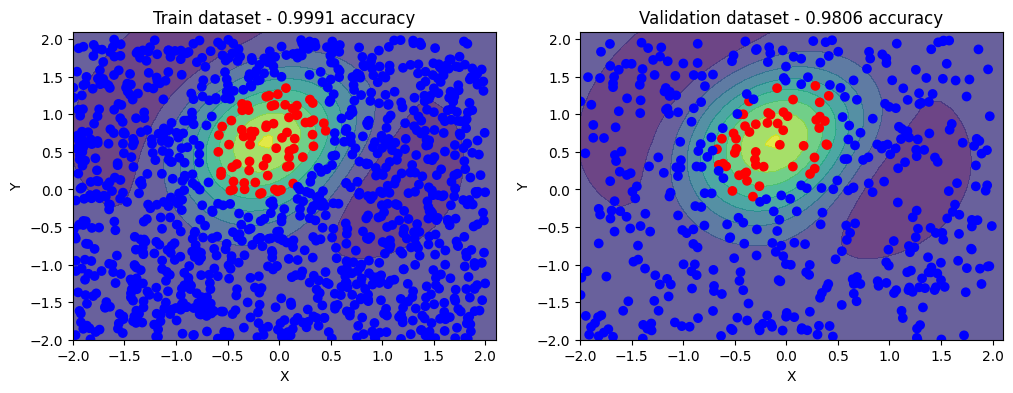

In [136]:
from sklearn.svm import SVC

model = SVC(kernel='rbf', gamma=1, C=1)
clf = model.fit(X_train, y_train)

xx, yy = np.meshgrid(np.arange(-2, 2.2, 0.1), np.arange(-2, 2.2, 0.1))
xy = np.c_[xx.ravel(), yy.ravel()]

P = model.decision_function(xy).reshape(xx.shape)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plot the training data on the first subplot
axs[0].contourf(xx, yy, P, alpha=0.8)
scatter1 = axs[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_title(f'Train dataset - {clf.score(X_train, y_train):.4f} accuracy')

# Plot the validation data on the second subplot
axs[1].contourf(xx, yy, P, alpha=0.8)
scatter2 = axs[1].scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap='bwr')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Y')
axs[1].set_title(f'Validation dataset - {clf.score(X_val, y_val):.4f} accuracy')

plt.show()

Now, we would like to improve the RBF accuracy. Use C=1 as before and you will tune gamma.

Print the graph for the gap between the train and the validation accuracy, as function of gamma.

1. What gamma should you take? What do you expect to happen?
2. What happens if you choose a gamma giving extermum?

<font color='red'>Write here your answer and explain it

1.Choosing gamma around 1.1 is advisable because it minimizes the accuracy gap between training and validation datasets, suggesting good generalization without overfitting or underfitting.With gamma around 1.1, the model should maintain a balance, offering good predictive performance on both(training) and(validation) data.  
2.Selecting a very low gamma value results in a larger accuracy gap, indicating underfitting, where the model is too simplistic.</font>

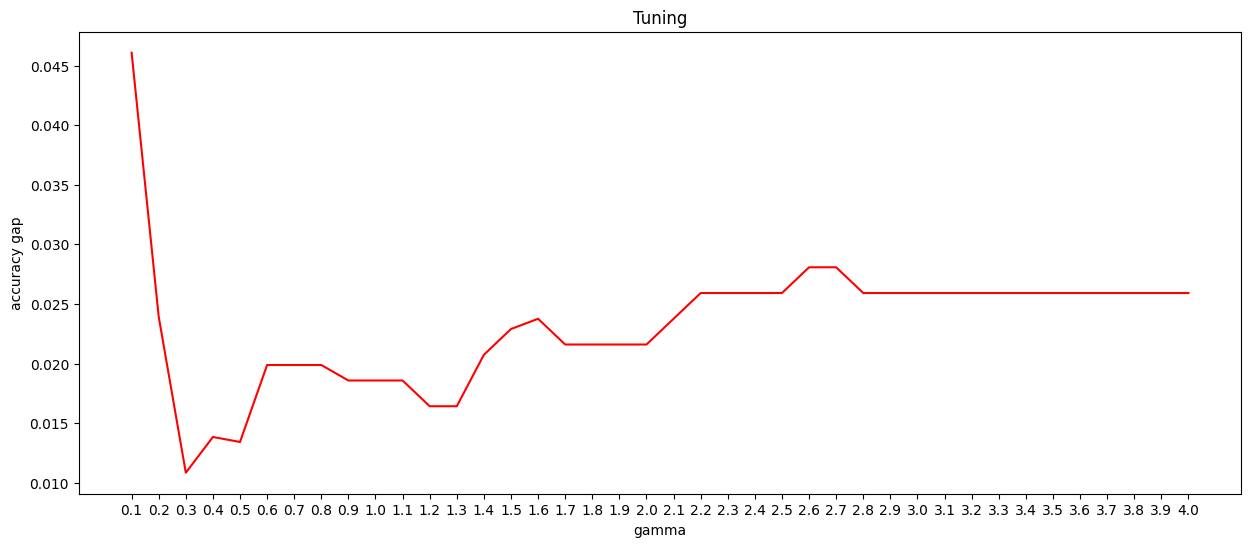

In [137]:
from sklearn.metrics import accuracy_score
gammas = np.arange(0.1, 4.1, 0.1)

acc_gaps = []
for gamma in gammas:
    model = SVC(kernel='rbf', gamma=gamma, C=1)
    model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_preds)

    val_preds = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_preds)

    #calculate the gap between training and validation accuracy
    acc_gap = train_acc - val_acc
    acc_gaps.append(acc_gap)

plt.figure(figsize=(15,6))
plt.plot(gammas, acc_gaps, color='red')
plt.xlabel('gamma')
plt.ylabel('accuracy gap')
plt.title('Tuning')
plt.xticks(gammas)
plt.show()

## Question 4 - 10 pts Bonus
See attached PDF in Moodle